In [41]:
!nvidia-smi


Mon Feb  2 16:52:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P0             27W /   70W |    1936MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [42]:
!pip -q install ultralytics roboflow opencv-python pillow pyyaml matplotlib pandas tqdm


In [43]:
import os

# ✅ Put your key here (better: use Colab secrets)
os.environ["ROBOFLOW_API_KEY"] = "6PWqdRK2WP8m7rhS9qRb"

print("✅ ROBOFLOW_API_KEY set:", "ROBOFLOW_API_KEY" in os.environ)


✅ ROBOFLOW_API_KEY set: True


In [44]:
from roboflow import Roboflow
import os

workspace_name = "daffodil-international-university-s5vpr"
project_name   = "merged-voyoh"
version_number = 1

rf = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"])
project = rf.workspace(workspace_name).project(project_name)

# ✅ This downloads to a folder and returns an object with `.location`
dataset = project.version(version_number).download("yolov8")

DATASET_DIR = dataset.location
print("✅ Downloaded dataset to:", DATASET_DIR)


loading Roboflow workspace...
loading Roboflow project...
✅ Downloaded dataset to: /content/Merged--1


In [45]:
import os, glob, yaml

yaml_candidates = glob.glob(os.path.join(DATASET_DIR, "*.yaml"))
print("YAML candidates:", yaml_candidates)

assert len(yaml_candidates) > 0, "❌ No YAML file found in dataset root."

DATA_YAML = yaml_candidates[0]
print("✅ Using data.yaml:", DATA_YAML)

with open(DATA_YAML, "r") as f:
    data = yaml.safe_load(f)

print("✅ Keys in yaml:", list(data.keys()))
print("\n--- data.yaml ---\n")
print(open(DATA_YAML, "r").read())


YAML candidates: ['/content/Merged--1/data.yaml']
✅ Using data.yaml: /content/Merged--1/data.yaml
✅ Keys in yaml: ['names', 'nc', 'roboflow', 'test', 'train', 'val']

--- data.yaml ---

names:
- A to Z
- A-C
- A-Cal D
- A-Calm
- AMycin
- ATOZ Senior
- ATV
- AU-20
- Abdalan
- Abdolax
- Abecab
- Abetis Plus
- Abetis
- Ace Plus
- Ace Power
- Ace XR
- Ace
- Acelex
- Acetram
- Acifix
- Aciphin
- Acitrin-L
- Acliz Plus
- Acos
- Acron
- Actrapid
- Adam 33
- Adlock
- Adora
- Adovas
- Advel
- Aeron
- Afix
- Afrin
- Airflow
- Alagra
- Alanil
- Alarup
- Alatrol
- Albasine
- Alben DS
- Alcet
- Alervil
- Alestor
- Alex
- Alfumax ER
- Algecal D
- Algecal DX
- Algecal
- Algicid DX
- Algicid
- Algin
- Algita D
- Alice
- Alkanon
- Allygest
- Almex
- Alneed
- Alovera
- Alphapress
- Alve
- Ambronil
- Ambrox
- Amdocal Plus
- Amdocal
- Amikacin
- Amilin Plus
- Amilin
- Amira
- Amit
- Amitriptyline
- Amlevo
- Amlocard
- Amlodipine
- Anadol
- Anaflex Max
- Anclog
- Ancor
- Androcap
- Anfree
- Angenta
- Angil

In [46]:
# names can be list OR dict depending on Roboflow export
names = data["names"]
if isinstance(names, dict):
    CLASS_NAMES = [names[i] for i in range(len(names))]
else:
    CLASS_NAMES = list(names)

print("✅ Number of classes:", len(CLASS_NAMES))
print("✅ First 30 class names:", CLASS_NAMES[:30])


✅ Number of classes: 1445
✅ First 30 class names: ['A to Z', 'A-C', 'A-Cal D', 'A-Calm', 'AMycin', 'ATOZ Senior', 'ATV', 'AU-20', 'Abdalan', 'Abdolax', 'Abecab', 'Abetis Plus', 'Abetis', 'Ace Plus', 'Ace Power', 'Ace XR', 'Ace', 'Acelex', 'Acetram', 'Acifix', 'Aciphin', 'Acitrin-L', 'Acliz Plus', 'Acos', 'Acron', 'Actrapid', 'Adam 33', 'Adlock', 'Adora', 'Adovas']


In [47]:
import glob, os

def count_split(split):
    img_dir = os.path.join(DATASET_DIR, split, "images")
    lbl_dir = os.path.join(DATASET_DIR, split, "labels")
    imgs = sorted(glob.glob(os.path.join(img_dir, "*")))
    lbls = sorted(glob.glob(os.path.join(lbl_dir, "*.txt")))
    return len(imgs), len(lbls), img_dir, lbl_dir

for split in ["train", "valid", "test"]:
    n_img, n_lbl, img_dir, lbl_dir = count_split(split)
    print(f"{split}: images={n_img} labels={n_lbl}")
    print("  img_dir:", img_dir)
    print("  lbl_dir:", lbl_dir)


train: images=622 labels=622
  img_dir: /content/Merged--1/train/images
  lbl_dir: /content/Merged--1/train/labels
valid: images=176 labels=176
  img_dir: /content/Merged--1/valid/images
  lbl_dir: /content/Merged--1/valid/labels
test: images=95 labels=95
  img_dir: /content/Merged--1/test/images
  lbl_dir: /content/Merged--1/test/labels


🖼 Image: /content/Merged--1/train/images/341212232_196272363190839_3783100550928590794_n_jpg.rf.aaddb329d37b48b251179504231b1d96.jpg
📄 Label: /content/Merged--1/train/labels/341212232_196272363190839_3783100550928590794_n_jpg.rf.aaddb329d37b48b251179504231b1d96.txt


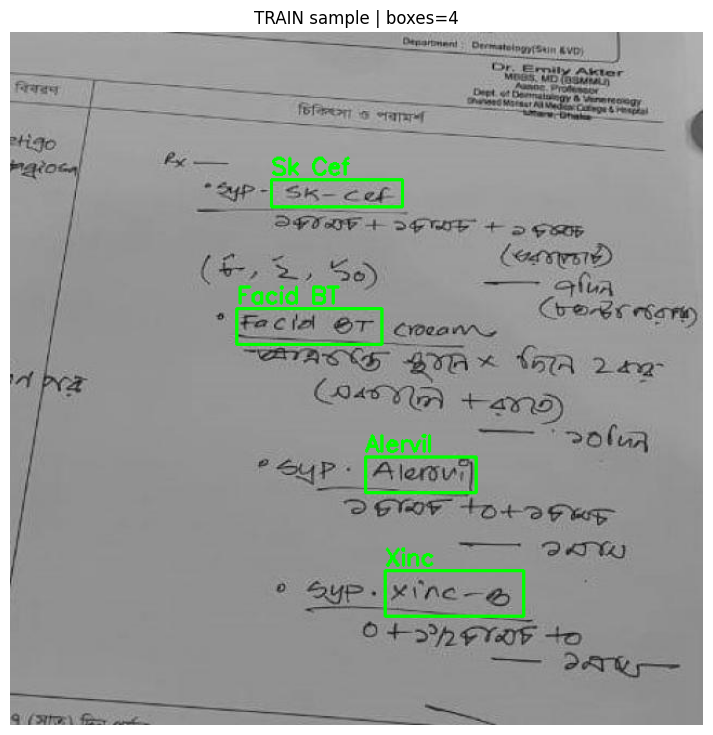

In [48]:
import random, os, glob
import cv2
import matplotlib.pyplot as plt

def yolo_to_xyxy(xc, yc, w, h, W, H):
    x1 = int((xc - w/2) * W)
    y1 = int((yc - h/2) * H)
    x2 = int((xc + w/2) * W)
    y2 = int((yc + h/2) * H)
    # clip
    x1 = max(0, min(W-1, x1))
    y1 = max(0, min(H-1, y1))
    x2 = max(0, min(W-1, x2))
    y2 = max(0, min(H-1, y2))
    return x1, y1, x2, y2

SPLIT = "train"
IMG_DIR = os.path.join(DATASET_DIR, SPLIT, "images")
LBL_DIR = os.path.join(DATASET_DIR, SPLIT, "labels")

images = sorted(glob.glob(os.path.join(IMG_DIR, "*")))
assert len(images) > 0, "❌ No images found in this split!"

img_path = random.choice(images)
stem = os.path.splitext(os.path.basename(img_path))[0]
lbl_path = os.path.join(LBL_DIR, stem + ".txt")

print("🖼 Image:", img_path)
print("📄 Label:", lbl_path)

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
H, W = img_rgb.shape[:2]

lines = []
if os.path.exists(lbl_path):
    with open(lbl_path, "r") as f:
        lines = [ln.strip().split() for ln in f if ln.strip()]

draw = img_rgb.copy()
for parts in lines:
    if len(parts) < 5:
        continue
    cls, xc, yc, bw, bh = parts[:5]
    cls = int(float(cls))
    xc, yc, bw, bh = map(float, (xc, yc, bw, bh))
    x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, bw, bh, W, H)

    cv2.rectangle(draw, (x1,y1), (x2,y2), (0,255,0), 2)
    name = CLASS_NAMES[cls] if 0 <= cls < len(CLASS_NAMES) else str(cls)
    cv2.putText(draw, name, (x1, max(20, y1-5)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

plt.figure(figsize=(9,9))
plt.imshow(draw)
plt.axis("off")
plt.title(f"{SPLIT.upper()} sample | boxes={len(lines)}")
plt.show()


In [49]:
import os, shutil, glob, yaml

SRC_DIR = DATASET_DIR  # your roboflow dataset root
DST_DIR = "/content/Merged_ROI_1class"
os.makedirs(DST_DIR, exist_ok=True)

print("SRC:", SRC_DIR)
print("DST:", DST_DIR)


SRC: /content/Merged--1
DST: /content/Merged_ROI_1class


In [50]:
import os, glob, shutil

def ensure_dirs(base, split):
    os.makedirs(os.path.join(base, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(base, split, "labels"), exist_ok=True)

def rewrite_labels_to_single_class(src_lbl_path, dst_lbl_path):
    # YOLO label format: cls xc yc w h [optional extras]
    out_lines = []
    with open(src_lbl_path, "r") as f:
        for ln in f:
            ln = ln.strip()
            if not ln:
                continue
            parts = ln.split()
            if len(parts) < 5:
                continue
            # force class id to 0, keep bbox coords
            out_lines.append("0 " + " ".join(parts[1:5]))
    with open(dst_lbl_path, "w") as f:
        f.write("\n".join(out_lines) + ("\n" if out_lines else ""))

for split in ["train", "valid", "test"]:
    ensure_dirs(DST_DIR, split)

    src_img_dir = os.path.join(SRC_DIR, split, "images")
    src_lbl_dir = os.path.join(SRC_DIR, split, "labels")

    dst_img_dir = os.path.join(DST_DIR, split, "images")
    dst_lbl_dir = os.path.join(DST_DIR, split, "labels")

    imgs = sorted(glob.glob(os.path.join(src_img_dir, "*")))
    print(split, "images:", len(imgs))

    for img_path in imgs:
        stem = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(src_lbl_dir, stem + ".txt")

        # copy image
        shutil.copy2(img_path, os.path.join(dst_img_dir, os.path.basename(img_path)))

        # rewrite label (if exists)
        if os.path.exists(lbl_path):
            rewrite_labels_to_single_class(lbl_path, os.path.join(dst_lbl_dir, stem + ".txt"))
        else:
            # create empty label file
            open(os.path.join(dst_lbl_dir, stem + ".txt"), "w").close()

print("✅ Done conversion to single class.")


train images: 622
valid images: 176
test images: 95
✅ Done conversion to single class.


In [51]:
import os, yaml

DATA_YAML_1C = os.path.join(DST_DIR, "data.yaml")
data_1c = {
    "path": DST_DIR,
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 1,
    "names": ["roi"]
}

with open(DATA_YAML_1C, "w") as f:
    yaml.safe_dump(data_1c, f, sort_keys=False)

print("✅ New data.yaml:", DATA_YAML_1C)
print(open(DATA_YAML_1C).read())


✅ New data.yaml: /content/Merged_ROI_1class/data.yaml
path: /content/Merged_ROI_1class
train: train/images
val: valid/images
test: test/images
nc: 1
names:
- roi



In [52]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data=DATA_YAML_1C,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    project="roi_runs_1class",
    name="yolov8n_roi"
)


Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Merged_ROI_1class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_roi2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pe

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79fffbe4a720>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [55]:
import glob, os

cands = glob.glob("**/best.pt", recursive=True)
print("Found best.pt files:", len(cands))
for p in cands[:50]:
    print(p)

assert len(cands) > 0, "❌ No best.pt found anywhere. Training likely did not finish."
BEST = sorted(cands, key=os.path.getmtime)[-1]
print("\n✅ Using latest best.pt:", BEST)



Found best.pt files: 2
runs/detect/roi_runs_1class/yolov8n_roi/weights/best.pt
runs/detect/roi_runs_1class/yolov8n_roi2/weights/best.pt

✅ Using latest best.pt: runs/detect/roi_runs_1class/yolov8n_roi2/weights/best.pt


In [57]:
import glob, os
from ultralytics import YOLO

best = "runs/detect/roi_runs_1class/yolov8n_roi/weights/best.pt"
assert os.path.exists(best), "❌ best.pt not found."
roi_model_1c = YOLO(best)

res = roi_model_1c.val(data=DATA_YAML_1C, split="test", device=0)
print("mAP50:", float(res.box.map50))
print("mAP50-95:", float(res.box.map))


Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1410.5±410.7 MB/s, size: 38.8 KB)
val: Scanning /content/Merged_ROI_1class/test/labels.cache... 95 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 95/95 39.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.2it/s 2.7s
                   all         95        402      0.827      0.846      0.869      0.515
Speed: 4.7ms preprocess, 5.4ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /content/runs/detect/val4
mAP50: 0.8686145661825107
mAP50-95: 0.5147516563790487


In [58]:
import glob, os
from ultralytics import YOLO

# Find latest best.pt
cands = glob.glob("/content/**/best.pt", recursive=True)
assert len(cands) > 0, "❌ best.pt not found anywhere."
BEST = sorted(cands, key=os.path.getmtime)[-1]
print("✅ Using best:", BEST)

roi_model = YOLO(BEST)


✅ Using best: /content/runs/detect/roi_runs_1class/yolov8n_roi2/weights/best.pt


In [60]:
import os, glob
import cv2
import pandas as pd
from tqdm import tqdm

IMG_ROOT = "/content/Merged_ROI_1class/test/images"   # change to any folder of full images
OUT_ROOT = "/content/roi_pred_crops"
os.makedirs(OUT_ROOT, exist_ok=True)

imgs = sorted(glob.glob(os.path.join(IMG_ROOT, "*")))
print("✅ Images:", len(imgs))

rows = []
crop_id = 0

PAD = 0.08      # padding around ROI
CONF = 0.25     # detection confidence
MAX_DET = 50    # max boxes per image

for img_path in tqdm(imgs, desc="Detect + crop"):
    bgr = cv2.imread(img_path)
    if bgr is None:
        continue
    H, W = bgr.shape[:2]

    r = roi_model.predict(img_path, conf=CONF, device=0, verbose=False, max_det=MAX_DET)[0]
    boxes = r.boxes

    if boxes is None or len(boxes) == 0:
        continue

    for b in boxes:
        x1, y1, x2, y2 = b.xyxy[0].cpu().numpy().tolist()
        conf = float(b.conf[0].cpu().numpy())

        # padding
        bw = x2 - x1
        bh = y2 - y1
        px = PAD * bw
        py = PAD * bh

        x1p = int(max(0, x1 - px))
        y1p = int(max(0, y1 - py))
        x2p = int(min(W-1, x2 + px))
        y2p = int(min(H-1, y2 + py))

        if x2p <= x1p or y2p <= y1p:
            continue

        crop = bgr[y1p:y2p, x1p:x2p]
        crop_name = f"{os.path.splitext(os.path.basename(img_path))[0]}_pred_{crop_id:06d}.jpg"
        crop_path = os.path.join(OUT_ROOT, crop_name)
        cv2.imwrite(crop_path, crop)

        rows.append({
            "orig_image": img_path,
            "crop_path": crop_path,
            "conf": conf,
            "x1": x1p, "y1": y1p, "x2": x2p, "y2": y2p
        })
        crop_id += 1

df_pred = pd.DataFrame(rows)
CSV = os.path.join(OUT_ROOT, "roi_pred_crops_metadata.csv")
df_pred.to_csv(CSV, index=False)

print("✅ Saved crops:", len(df_pred))
print("✅ Saved CSV:", CSV)
df_pred.head()


✅ Images: 95


Detect + crop: 100%|██████████| 95/95 [00:01<00:00, 69.66it/s]

✅ Saved crops: 418
✅ Saved CSV: /content/roi_pred_crops/roi_pred_crops_metadata.csv


,orig_image,crop_path,conf,x1,y1,x2,y2
0,/content/Merged_ROI_1class/test/images/1586448...,/content/roi_pred_crops/158644895_882858708940...,0.748340,336,209,460,240
1,/content/Merged_ROI_1class/test/images/1586448...,/content/roi_pred_crops/158644895_882858708940...,0.621353,367,330,512,358
2,/content/Merged_ROI_1class/test/images/1586448...,/content/roi_pred_crops/158644895_882858708940...,0.323858,377,270,442,297
3,/content/Merged_ROI_1class/test/images/2746109...,/content/roi_pred_crops/274610921_174984107868...,0.710134,311,356,401,395
4,/content/Merged_ROI_1class/test/images/2746109...,/content/roi_pred_crops/274610921_174984107868...,0.435653,302,419,395,475


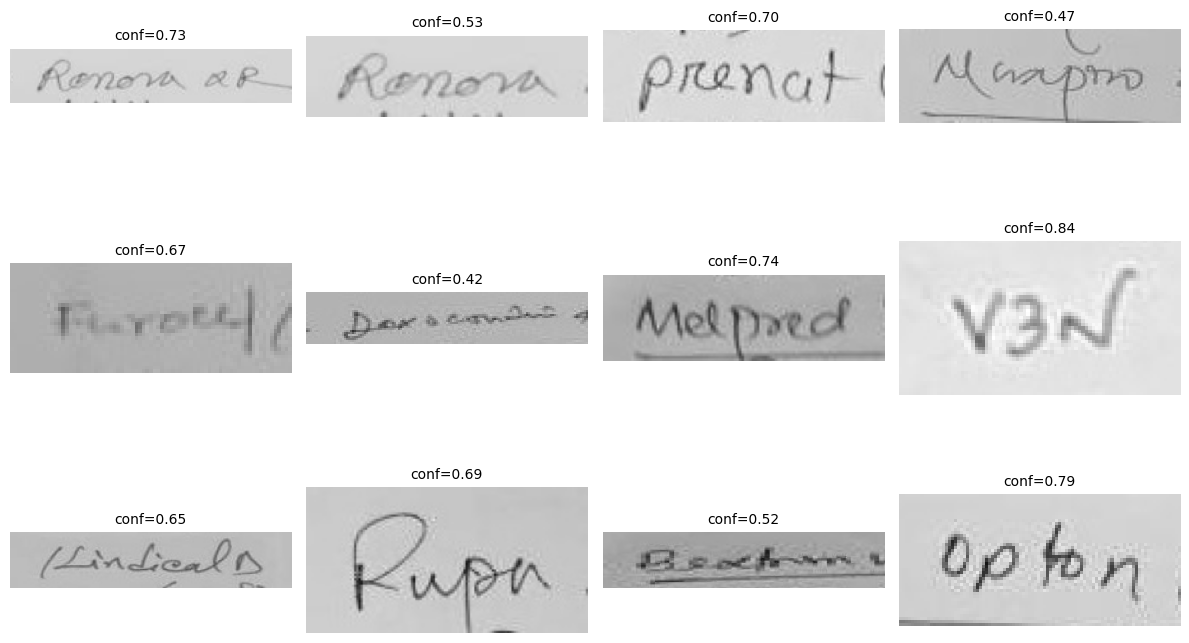

In [61]:
import random, cv2
import matplotlib.pyplot as plt

SHOW = 12
sample = df_pred.sample(min(SHOW, len(df_pred)), random_state=42).reset_index(drop=True)

plt.figure(figsize=(12, 8))
for i in range(len(sample)):
    p = sample.loc[i, "crop_path"]
    conf = sample.loc[i, "conf"]
    img = cv2.imread(p)
    if img is None:
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(3, 4, i+1)
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"conf={conf:.2f}", fontsize=10)

plt.tight_layout()
plt.show()


In [62]:
import os, glob
import cv2
import numpy as np

GT_ROOT = "/content/Merged_ROI_1class"   # 1-class dataset root (has images/labels)
# BUT we need the original dataset with real class names for mapping
ORIG_ROOT = "/content/Merged--1"         # original dataset with many class names
# If your original dataset path is different, change it.

# Use CLASS_NAMES from the original data.yaml (many classes)
import yaml
orig_yaml = os.path.join(ORIG_ROOT, "data.yaml")
with open(orig_yaml, "r") as f:
    d = yaml.safe_load(f)

names = d["names"]
if isinstance(names, dict):
    CLASS_NAMES_ORIG = [names[i] for i in range(len(names))]
else:
    CLASS_NAMES_ORIG = list(names)

print("✅ Original class count:", len(CLASS_NAMES_ORIG))

def yolo_to_xyxy_abs(xc, yc, w, h, W, H):
    x1 = (xc - w/2) * W
    y1 = (yc - h/2) * H
    x2 = (xc + w/2) * W
    y2 = (yc + h/2) * H
    return x1, y1, x2, y2

def load_gt_for_split(split):
    img_dir = os.path.join(ORIG_ROOT, split, "images")
    lbl_dir = os.path.join(ORIG_ROOT, split, "labels")

    gt_map = {}  # img_path -> list of (x1,y1,x2,y2,cls_id)
    imgs = sorted(glob.glob(os.path.join(img_dir, "*")))

    for img_path in imgs:
        stem = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(lbl_dir, stem + ".txt")
        if not os.path.exists(lbl_path):
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue
        H, W = img.shape[:2]

        boxes = []
        with open(lbl_path, "r") as f:
            for ln in f:
                ln = ln.strip()
                if not ln:
                    continue
                parts = ln.split()
                if len(parts) < 5:
                    continue
                cls = int(float(parts[0]))
                xc, yc, bw, bh = map(float, parts[1:5])
                x1, y1, x2, y2 = yolo_to_xyxy_abs(xc, yc, bw, bh, W, H)
                boxes.append((x1, y1, x2, y2, cls))

        if boxes:
            gt_map[img_path] = boxes

    return gt_map

# Load GT map for the split you are visualizing (your screenshot is from test)
gt_map_test = load_gt_for_split("test")
print("✅ GT images loaded:", len(gt_map_test))


✅ Original class count: 1445
✅ GT images loaded: 95


In [63]:
def iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)
    iw = max(0.0, inter_x2 - inter_x1)
    ih = max(0.0, inter_y2 - inter_y1)
    inter = iw * ih
    area_a = max(0.0, ax2-ax1) * max(0.0, ay2-ay1)
    area_b = max(0.0, bx2-bx1) * max(0.0, by2-by1)
    union = area_a + area_b - inter + 1e-9
    return inter / union

def match_pred_to_gt_name(orig_image_path, pred_xyxy, gt_map, iou_thr=0.3):
    # Find corresponding GT list for this image
    gts = gt_map.get(orig_image_path, [])
    if not gts:
        return None, 0.0

    best_iou = 0.0
    best_cls = None
    for (x1, y1, x2, y2, cls) in gts:
        i = iou_xyxy(pred_xyxy, (x1, y1, x2, y2))
        if i > best_iou:
            best_iou = i
            best_cls = cls

    if best_iou >= iou_thr and best_cls is not None and 0 <= best_cls < len(CLASS_NAMES_ORIG):
        return CLASS_NAMES_ORIG[best_cls], best_iou
    return None, best_iou


In [64]:
import pandas as pd

# IMPORTANT:
# df_pred["orig_image"] must point to ORIGINAL test image paths inside ORIG_ROOT/test/images
# If your df_pred orig_image points to /content/Merged_ROI_1class/test/images,
# we must map it to ORIG_ROOT/test/images by filename.

def to_orig_test_path(p):
    fn = os.path.basename(p)
    return os.path.join(ORIG_ROOT, "test", "images", fn)

df_pred = df_pred.copy()
df_pred["orig_image_origroot"] = df_pred["orig_image"].apply(to_orig_test_path)

names = []
ious = []
for _, row in df_pred.iterrows():
    pred_xyxy = (row["x1"], row["y1"], row["x2"], row["y2"])
    nm, biou = match_pred_to_gt_name(row["orig_image_origroot"], pred_xyxy, gt_map_test, iou_thr=0.3)
    names.append(nm if nm is not None else "UNKNOWN")
    ious.append(biou)

df_pred["matched_name"] = names
df_pred["match_iou"] = ious

print(df_pred[["crop_path","conf","matched_name","match_iou"]].head(10))


                                           crop_path      conf  matched_name  \
0  /content/roi_pred_crops/158644895_882858708940...  0.748340        Azomac   
1  /content/roi_pred_crops/158644895_882858708940...  0.621353      Fexofast   
2  /content/roi_pred_crops/158644895_882858708940...  0.323858        Xpa XR   
3  /content/roi_pred_crops/274610921_174984107868...  0.710134      Nexcital   
4  /content/roi_pred_crops/274610921_174984107868...  0.435653      Rivotril   
5  /content/roi_pred_crops/274610921_174984107868...  0.251618        Sentix   
6  /content/roi_pred_crops/282485613_325569979133...  0.728327       Firmvit   
7  /content/roi_pred_crops/282485613_325569979133...  0.682016         Almex   
8  /content/roi_pred_crops/282485613_325569979133...  0.465672          Brom   
9  /content/roi_pred_crops/282558379_325569891799...  0.517309  Bextram Gold   

   match_iou  
0   0.713515  
1   0.688300  
2   0.694051  
3   0.818277  
4   0.774221  
5   0.759872  
6   0.650773  

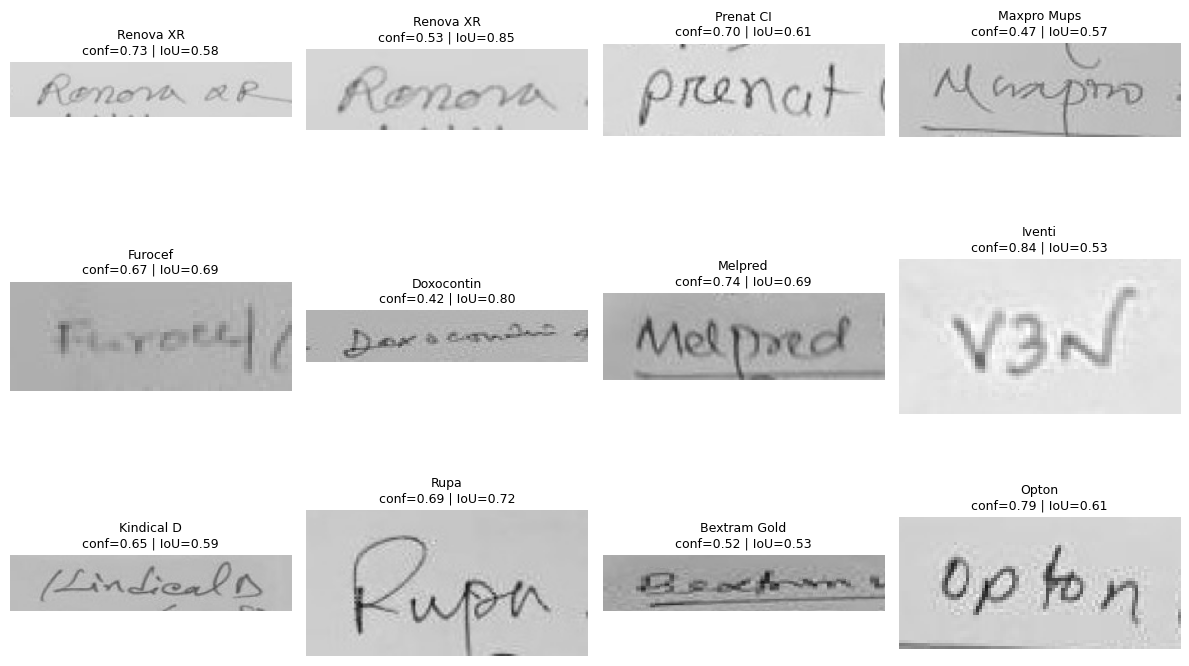

In [65]:
import matplotlib.pyplot as plt
import cv2

SHOW = 12
sample = df_pred.sample(min(SHOW, len(df_pred)), random_state=42).reset_index(drop=True)

plt.figure(figsize=(12, 8))
for i in range(len(sample)):
    cp = sample.loc[i, "crop_path"]
    conf = sample.loc[i, "conf"]
    nm   = sample.loc[i, "matched_name"]
    iou  = sample.loc[i, "match_iou"]

    img = cv2.imread(cp)
    if img is None:
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 4, i+1)
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"{nm}\nconf={conf:.2f} | IoU={iou:.2f}", fontsize=9)

plt.tight_layout()
plt.show()


In [66]:
!pip -q install torch torchvision torchaudio rapidfuzz tqdm pillow opencv-python pandas matplotlib


In [67]:
import os, glob

# Common candidates in Colab after Roboflow download
cands = []
for p in glob.glob("/content/*"):
    if os.path.isdir(p) and os.path.exists(os.path.join(p, "data.yaml")):
        cands.append(p)

print("Candidates with data.yaml:")
for p in cands:
    print(" -", p)

# If you know it's /content/Merged--1, set it directly:
ORIG_ROOT = "/content/Merged--1"
print("\nTrying ORIG_ROOT:", ORIG_ROOT, "exists:", os.path.exists(ORIG_ROOT))


Candidates with data.yaml:
 - /content/Merged--1
 - /content/Merged_ROI_1class

Trying ORIG_ROOT: /content/Merged--1 exists: True


In [69]:
import yaml, os

DATA_YAML_ORIG = os.path.join(ORIG_ROOT, "data.yaml")
assert os.path.exists(DATA_YAML_ORIG), f"❌ data.yaml not found at: {DATA_YAML_ORIG}"

with open(DATA_YAML_ORIG, "r") as f:
    data = yaml.safe_load(f)

names = data["names"]
if isinstance(names, dict):
    CLASS_NAMES = [names[i] for i in range(len(names))]
else:
    CLASS_NAMES = list(names)

print("✅ Classes:", len(CLASS_NAMES))
print("First 20:", CLASS_NAMES[:20])


✅ Classes: 1445
First 20: ['A to Z', 'A-C', 'A-Cal D', 'A-Calm', 'AMycin', 'ATOZ Senior', 'ATV', 'AU-20', 'Abdalan', 'Abdolax', 'Abecab', 'Abetis Plus', 'Abetis', 'Ace Plus', 'Ace Power', 'Ace XR', 'Ace', 'Acelex', 'Acetram', 'Acifix']


In [71]:
import os, glob, cv2
import pandas as pd
from tqdm import tqdm

OUT_CROP_ROOT = "/content/roboflow_gt_crops"
os.makedirs(OUT_CROP_ROOT, exist_ok=True)

def yolo_to_xyxy(xc, yc, w, h, W, H):
    x1 = int((xc - w/2) * W)
    y1 = int((yc - h/2) * H)
    x2 = int((xc + w/2) * W)
    y2 = int((yc + h/2) * H)
    # clip
    x1 = max(0, min(W-1, x1))
    y1 = max(0, min(H-1, y1))
    x2 = max(0, min(W-1, x2))
    y2 = max(0, min(H-1, y2))
    return x1, y1, x2, y2

def crop_from_split(split, pad=0.08):
    img_dir = os.path.join(ORIG_ROOT, split, "images")
    lbl_dir = os.path.join(ORIG_ROOT, split, "labels")
    assert os.path.isdir(img_dir), f"❌ Missing: {img_dir}"
    assert os.path.isdir(lbl_dir), f"❌ Missing: {lbl_dir}"

    out_dir = os.path.join(OUT_CROP_ROOT, split)
    os.makedirs(out_dir, exist_ok=True)

    rows = []
    imgs = sorted(glob.glob(os.path.join(img_dir, "*")))

    for img_path in tqdm(imgs, desc=f"Cropping {split}"):
        stem = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(lbl_dir, stem + ".txt")
        if not os.path.exists(lbl_path):
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue
        H, W = img.shape[:2]

        with open(lbl_path, "r") as f:
            lines = [ln.strip().split() for ln in f if ln.strip()]

        for j, parts in enumerate(lines):
            if len(parts) < 5:
                continue
            cls = int(float(parts[0]))
            xc, yc, bw, bh = map(float, parts[1:5])

            x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, bw, bh, W, H)

            # padding
            px = int((x2 - x1) * pad)
            py = int((y2 - y1) * pad)
            x1p = max(0, x1 - px); y1p = max(0, y1 - py)
            x2p = min(W-1, x2 + px); y2p = min(H-1, y2 + py)

            if x2p <= x1p or y2p <= y1p:
                continue

            crop = img[y1p:y2p, x1p:x2p]
            cls_name = CLASS_NAMES[cls] if 0 <= cls < len(CLASS_NAMES) else str(cls)

            crop_path = os.path.join(out_dir, f"{stem}_gt_{j:03d}_c{cls}.jpg")
            cv2.imwrite(crop_path, crop)

            rows.append({
                "split": split,
                "orig_image": img_path,
                "label_file": lbl_path,
                "crop_path": crop_path,
                "cls_id": cls,
                "cls_name": cls_name,
                "x1": x1p, "y1": y1p, "x2": x2p, "y2": y2p
            })

    print(f"[{split}] ✅ Crops:", len(rows))
    return rows

all_rows = []
for split in ["train", "valid", "test"]:
    all_rows += crop_from_split(split, pad=0.08)

df_crops = pd.DataFrame(all_rows)
CSV_PATH = os.path.join(OUT_CROP_ROOT, "gt_crops_metadata.csv")
df_crops.to_csv(CSV_PATH, index=False)

print("\n✅ TOTAL crops:", len(df_crops))
print("✅ Saved:", CSV_PATH)
df_crops.head()


Cropping train: 100%|██████████| 622/622 [00:01<00:00, 386.06it/s]


[train] ✅ Crops: 2838


Cropping valid: 100%|██████████| 176/176 [00:00<00:00, 406.25it/s]


[valid] ✅ Crops: 799


Cropping test: 100%|██████████| 95/95 [00:00<00:00, 405.85it/s]


[test] ✅ Crops: 402

✅ TOTAL crops: 4039
✅ Saved: /content/roboflow_gt_crops/gt_crops_metadata.csv


,split,orig_image,label_file,crop_path,cls_id,cls_name,x1,y1,x2,y2
0,train,/content/Merged--1/train/images/20230314_20144...,/content/Merged--1/train/labels/20230314_20144...,/content/roboflow_gt_crops/train/20230314_2014...,90,Anuva,424,258,531,288
1,train,/content/Merged--1/train/images/20230314_20144...,/content/Merged--1/train/labels/20230314_20144...,/content/roboflow_gt_crops/train/20230314_2014...,1022,Paricel,453,348,549,374
2,train,/content/Merged--1/train/images/20230314_20144...,/content/Merged--1/train/labels/20230314_20144...,/content/roboflow_gt_crops/train/20230314_2014...,371,Deflux,442,393,558,430
3,train,/content/Merged--1/train/images/20230314_20144...,/content/Merged--1/train/labels/20230314_20144...,/content/roboflow_gt_crops/train/20230314_2014...,1218,Solas,457,471,530,496
4,train,/content/Merged--1/train/images/20230314_20144...,/content/Merged--1/train/labels/20230314_20144...,/content/roboflow_gt_crops/train/20230314_2014...,326,Coralcal DX,447,517,604,554


In [72]:
import os, glob
print("CSV exists:", os.path.exists("/content/roboflow_gt_crops/gt_crops_metadata.csv"))
print("Sample crops:", glob.glob("/content/roboflow_gt_crops/train/*.jpg")[:5])


CSV exists: True
Sample crops: ['/content/roboflow_gt_crops/train/340150386_568511691751207_8874639619233414358_n_jpg.rf.2290ae36a41d4d61327f6f99a4d522d3_gt_002_c608.jpg', '/content/roboflow_gt_crops/train/received_6298937343500299_jpeg.rf.9a48cb557dcdde5e64cac4e053e5eecb_gt_001_c461.jpg', '/content/roboflow_gt_crops/train/WhatsApp-Image-2023-04-12-at-12-48-16-AM_jpeg.rf.ceb5f3e454f60126ea359692b7429081_gt_000_c1207.jpg', '/content/roboflow_gt_crops/train/received_908109136938851_jpeg.rf.a58af36dc910fd69f5b7c7371ae74cb0_gt_003_c1061.jpg', '/content/roboflow_gt_crops/train/340460175_772521710891669_8498397083419418235_n_jpg.rf.1bd2f05b5b8f53c970f9c004c4d41651_gt_007_c373.jpg']


In [73]:
import os
import pandas as pd

GT_META = "/content/roboflow_gt_crops/gt_crops_metadata.csv"
assert os.path.exists(GT_META), f"❌ Not found: {GT_META}"

df = pd.read_csv(GT_META)

# text label = class name
df["text"] = df["cls_name"].astype(str).str.strip()

# keep valid
df = df[df["crop_path"].apply(os.path.exists)]
df = df[df["text"].str.len() > 0].reset_index(drop=True)

train_df = df[df["split"]=="train"][["crop_path","text"]].reset_index(drop=True)
val_df   = df[df["split"]=="valid"][["crop_path","text"]].reset_index(drop=True)
test_df  = df[df["split"]=="test"][["crop_path","text"]].reset_index(drop=True)

print("✅ OCR pairs:")
print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

train_df.head()


✅ OCR pairs:
Train: 2838
Val:   799
Test:  402


,crop_path,text
0,/content/roboflow_gt_crops/train/20230314_2014...,Anuva
1,/content/roboflow_gt_crops/train/20230314_2014...,Paricel
2,/content/roboflow_gt_crops/train/20230314_2014...,Deflux
3,/content/roboflow_gt_crops/train/20230314_2014...,Solas
4,/content/roboflow_gt_crops/train/20230314_2014...,Coralcal DX


In [74]:
#text normalization + build CTC vocabulary

import json

def normalize_text(s: str) -> str:
    s = str(s).lower().strip()
    s = " ".join(s.split())
    return s

# normalize all labels
train_df["text"] = train_df["text"].apply(normalize_text)
val_df["text"]   = val_df["text"].apply(normalize_text)
test_df["text"]  = test_df["text"].apply(normalize_text)

# Define a complete character set BEFORE building from data
REQUIRED_CHARS = set('0123456789abcdefghijklmnopqrstuvwxyz -')
# build charset from TRAIN only
charset = set()
for t in train_df["text"].tolist():
    for ch in t:
        charset.add(ch)
# Merge with required characters
charset = charset.union(REQUIRED_CHARS)

# CTC requires blank at index 0
chars = ["[blank]"] + sorted(list(charset))
char2idx = {c:i for i,c in enumerate(chars)}
idx2char = {i:c for c,i in char2idx.items()}

print("✅ Vocab size:", len(chars))
print("Sample chars:", chars[:60])

# save vocab
VOCAB_PATH = "/content/ctc_vocab.json"
with open(VOCAB_PATH, "w", encoding="utf-8") as f:
    json.dump({"chars": chars}, f, ensure_ascii=False, indent=2)

print("✅ Saved vocab to:", VOCAB_PATH)


✅ Vocab size: 39
Sample chars: ['[blank]', ' ', '-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
✅ Saved vocab to: /content/ctc_vocab.json


In [75]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np

IMG_H = 32
MAX_W = 256   # increase to 320 if words get cut

def resize_pad_grayscale(pil_img, img_h=32, max_w=256):
    img = pil_img.convert("L")
    w, h = img.size

    # Calculate new width maintaining aspect ratio
    new_w = int(w * (img_h / max(1, h)))
    new_w = max(1, min(new_w, max_w))
    img = img.resize((new_w, img_h), Image.LANCZOS)  # Better interpolation

    arr = np.array(img).astype(np.float32)

    # Normalize FIRST
    arr = (arr / 255.0 - 0.5) / 0.5  # Now in [-1, 1]

    # Then pad with normalized white value (1.0)
    if new_w < max_w:
        pad = np.ones((img_h, max_w - new_w), dtype=np.float32)  # Normalized white
        arr = np.concatenate([arr, pad], axis=1)

    return arr

from torchvision import transforms
import random

class WordDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        img = Image.open(row["crop_path"]).convert("RGB")

        # Apply random augmentation during training
        if self.augment:
            img = self.random_augment(img)

        arr = resize_pad_grayscale(img, IMG_H, MAX_W)
        x = torch.tensor(arr).unsqueeze(0)
        y = row["text"]
        return x, y

    def random_augment(self, img):
        """Apply random augmentations to improve generalization"""
        # Random brightness
        if random.random() > 0.5:
            from PIL import ImageEnhance
            enhancer = ImageEnhance.Brightness(img)
            img = enhancer.enhance(random.uniform(0.8, 1.2))

        # Random contrast
        if random.random() > 0.5:
            from PIL import ImageEnhance
            enhancer = ImageEnhance.Contrast(img)
            img = enhancer.enhance(random.uniform(0.8, 1.2))

        # Random rotation (small angles)
        if random.random() > 0.5:
            angle = random.uniform(-3, 3)
            img = img.rotate(angle, fillcolor='white')

        return img

# Update dataset creation
train_loader = DataLoader(
    WordDataset(train_df, augment=True),  # Enable augmentation for training
    batch_size=BATCH,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)


In [76]:
# ========================================
# CTCEncoder Class Definition
# This should be in a cell AFTER vocabulary creation
# and BEFORE creating data loaders
# ========================================

class CTCEncoder:
    def __init__(self, char2idx, idx2char, blank_idx=0):
        self.char2idx = char2idx
        self.idx2char = idx2char
        self.blank_idx = blank_idx

    def encode(self, texts):
        targets = []
        lengths = []
        for t in texts:
            ids = [self.char2idx[ch] for ch in t if ch in self.char2idx]
            targets.extend(ids)
            lengths.append(len(ids))
        return torch.tensor(targets, dtype=torch.long), torch.tensor(lengths, dtype=torch.long)

    def greedy_decode(self, log_probs):
        """Original greedy decoding - fast but less accurate"""
        # log_probs: (T,N,C)
        preds = log_probs.argmax(2).cpu().numpy()
        T, N = preds.shape
        out = []
        for n in range(N):
            seq = preds[:, n].tolist()
            s = []
            prev = None
            for p in seq:
                if p != self.blank_idx and p != prev:
                    s.append(self.idx2char[p])
                prev = p
            out.append("".join(s))
        return out

    def beam_search_decode(self, log_probs, beam_width=5):
        """Beam search decoding for better accuracy"""
        T, N, C = log_probs.shape
        results = []

        for n in range(N):
            probs = log_probs[:, n, :].cpu().numpy()

            # Initialize beam
            beams = [([], 0.0)]  # (sequence, score)

            for t in range(T):
                new_beams = []
                for seq, score in beams:
                    for c in range(C):
                        new_seq = seq + [c]
                        new_score = score + probs[t, c]
                        new_beams.append((new_seq, new_score))

                # Keep top beam_width candidates
                beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_width]

            # Get best sequence
            best_seq = beams[0][0]

            # Decode with CTC rules
            s = []
            prev = None
            for p in best_seq:
                if p != self.blank_idx and p != prev:
                    s.append(self.idx2char[p])
                prev = p

            results.append("".join(s))

        return results


# ========================================
# Initialize encoder
# ========================================
encoder = CTCEncoder(char2idx, idx2char, blank_idx=0)

In [77]:
# ========================================
# 1. FIRST: Define batch size
# ========================================
BATCH = 32  # Reduced from 64 for better gradient updates

# ========================================
# 2. SECOND: Create data loaders
# ========================================
train_loader = DataLoader(
    WordDataset(train_df, augment=True),  # Enable augmentation for training!
    batch_size=BATCH,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    WordDataset(val_df, augment=False),  # No augmentation for validation
    batch_size=BATCH,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    WordDataset(test_df, augment=False),  # No augmentation for test
    batch_size=BATCH,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("✅ Batches:", len(train_loader), len(val_loader), len(test_loader))

# ========================================
# 3. THIRD: Define model (before optimizer!)
# ========================================
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CRNN(nclass=len(chars), nh=512).to(device)  # Increased from 256 to 512

# ========================================
# 4. FOURTH: Define optimizer (AFTER model)
# ========================================
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,  # Lower learning rate
    weight_decay=1e-4  # L2 regularization
)

# ========================================
# 5. FIFTH: Define loss function
# ========================================
ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)

print("✅ Model ready on:", device)

✅ Batches: 89 25 13
✅ Model ready on: cuda


In [78]:
import torch.nn as nn

class BiLSTM(nn.Module):
    def __init__(self, nIn, nHidden, nOut):
        super().__init__()
        self.rnn = nn.LSTM(nIn, nHidden, bidirectional=True)
        self.fc = nn.Linear(nHidden*2, nOut)

    def forward(self, x):
        y, _ = self.rnn(x)
        T, N, H2 = y.size()
        y = self.fc(y.reshape(T*N, H2)).reshape(T, N, -1)
        return y

class CRNN(nn.Module):
    def __init__(self, nclass, nh=512):  # Increase from 256 to 512
        super().__init__()
        self.cnn = nn.Sequential(
            # Add BatchNorm to first layers for better training stability
            nn.Conv2d(1, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, 3, 1, 1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.Conv2d(256, 256, 3, 1, 1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.MaxPool2d((2, 1), (2, 1)),

            nn.Conv2d(256, 512, 3, 1, 1), nn.BatchNorm2d(512), nn.ReLU(True),
            nn.Conv2d(512, 512, 3, 1, 1), nn.BatchNorm2d(512), nn.ReLU(True),
            nn.MaxPool2d((2, 1), (2, 1)),

            nn.Conv2d(512, 512, 2, 1, 0), nn.BatchNorm2d(512), nn.ReLU(True)
        )

        # Increase to 3 layers and larger hidden size
        self.rnn = nn.Sequential(
            BiLSTM(512, nh, nh),
            BiLSTM(nh, nh, nh),  # Add one more layer
            BiLSTM(nh, nh, nclass)
        )

    def forward(self, x):
        conv = self.cnn(x)            # (N,512,1,W')
        conv = conv.squeeze(2)        # (N,512,W')
        conv = conv.permute(2, 0, 1)  # (T,N,512)
        out = self.rnn(conv)          # (T,N,C)
        return out.log_softmax(2)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = CRNN(nclass=len(chars)).to(device)

ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("✅ Model ready on:", device)


✅ Model ready on: cuda


In [79]:
from rapidfuzz.distance import Levenshtein

def cer(pred, gt):
    if len(gt) == 0:
        return 0 if len(pred) == 0 else 1
    return Levenshtein.distance(pred, gt) / max(1, len(gt))

@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss, total_cer, total, exact = 0.0, 0.0, 0, 0

    for imgs, texts in loader:
        imgs = imgs.to(device)
        texts = list(texts)

        log_probs = model(imgs)
        T, N, C = log_probs.shape
        input_lengths = torch.full((N,), T, dtype=torch.long)

        targets, target_lengths = encoder.encode(texts)
        loss = ctc_loss(log_probs, targets, input_lengths, target_lengths)

        preds = encoder.greedy_decode(log_probs)
        for p, g in zip(preds, texts):
            p = normalize_text(p)
            g = normalize_text(g)
            total_cer += cer(p, g)
            exact += int(p == g)
            total += 1

        total_loss += loss.item() * N

    return {
        "loss": total_loss / max(1, total),
        "cer": total_cer / max(1, total),
        "word_acc": exact / max(1, total)
    }

print("✅ Sanity val check:", evaluate(val_loader))


✅ Sanity val check: {'loss': 30.76400984333215, 'cer': 0.9614024898755821, 'word_acc': 0.0}


In [82]:
class EarlyStopping:
    def __init__(self, patience=15, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0
        return self.early_stop

from tqdm import tqdm
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.cuda.amp import GradScaler, autocast # Import GradScaler and autocast

# Configuration
EPOCHS = 200
PATIENCE = 20
BEST_PATH = "/content/best_crnn_medicine_ocr.pth"

# Initialize scheduler
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)
# Initialize mixed precision scaler
scaler = GradScaler()  # ┄ ADD THIS
# Early stopping variables
best_val_cer = 1e9
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running, seen = 0.0, 0

    for imgs, texts in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
        imgs = imgs.to(device)
        texts = list(texts)

        # ┄ WRAP FORWARD PASS WITH AUTOCAST
        with autocast():
            log_probs = model(imgs)
            T, N, C = log_probs.shape
            input_lengths = torch.full((N,), T, dtype=torch.long)

            targets, target_lengths = encoder.encode(texts)
            loss = ctc_loss(log_probs, targets, input_lengths, target_lengths)

        # ┄ REPLACE STANDARD BACKWARD WITH SCALED BACKWARD
        optimizer.zero_grad()
        scaler.scale(loss).backward()  # ┄ CHANGED
        scaler.unscale_(optimizer)  # ┄ ADD THIS (for gradient clipping)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)  # ┄ CHANGED
        scaler.update()  # ┄ ADD THIS


        running += loss.item() * N
        seen += N

    train_loss = running / max(1, seen)
    val_metrics = evaluate(val_loader)

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_CER={val_metrics['cer']:.4f} | "
        f"val_acc={val_metrics['word_acc']:.4f}"
    )

    # Update learning rate based on validation CER
    scheduler.step(val_metrics['cer'])

    # Save best model
    if val_metrics["cer"] < best_val_cer:
        best_val_cer = val_metrics["cer"]
        patience_counter = 0  # Reset counter
        torch.save(
            {
                "model": model.state_dict(),
                "chars": chars,
                "IMG_H": IMG_H,
                "MAX_W": MAX_W,
                "epoch": epoch,
                "val_cer": best_val_cer,
            },
            BEST_PATH,
        )
        print(f"✅ Saved BEST model | CER: {best_val_cer:.4f}")
    else:
        patience_counter += 1
        print(f"⏳ No improvement for {patience_counter}/{PATIENCE} epochs")

    # Early stopping check
    if patience_counter >= PATIENCE:
        print(f"❌ Early stopping triggered at epoch {epoch}")
        print(f"   Best validation CER: {best_val_cer:.4f}")
        break

print(f"\n🎉 Training completed!")
print(f"   Best CER: {best_val_cer:.4f}")
print(f"   Model saved to: {BEST_PATH}")

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
Epoch 1/200: 100%|██████████| 89/89 [00:05<00:00, 15.22it/s]


Epoch 001 | train_loss=4.8927 | val_loss=3.3126 | val_CER=1.0000 | val_acc=0.0000
✅ Saved BEST model | CER: 1.0000


Epoch 2/200: 100%|██████████| 89/89 [00:05<00:00, 15.03it/s]


Epoch 002 | train_loss=3.3031 | val_loss=3.2919 | val_CER=1.0000 | val_acc=0.0000
⏳ No improvement for 1/20 epochs


Epoch 3/200: 100%|██████████| 89/89 [00:05<00:00, 16.18it/s]


...

Epoch 058 | train_loss=2.8475 | val_loss=2.9224 | val_CER=0.8550 | val_acc=0.0000
⏳ No improvement for 18/20 epochs


Epoch 59/200: 100%|██████████| 89/89 [00:05<00:00, 15.95it/s]


Epoch 059 | train_loss=2.8421 | val_loss=2.9148 | val_CER=0.8550 | val_acc=0.0000
⏳ No improvement for 19/20 epochs


Epoch 60/200: 100%|██████████| 89/89 [00:06<00:00, 14.07it/s]


Epoch 060 | train_loss=2.8427 | val_loss=2.9133 | val_CER=0.8533 | val_acc=0.0000
⏳ No improvement for 20/20 epochs
❌ Early stopping triggered at epoch 60
   Best validation CER: 0.8493

🎉 Training completed!
   Best CER: 0.8493
   Model saved to: /content/best_crnn_medicine_ocr.pth


In [83]:
ckpt = torch.load(BEST_PATH, map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()

print("✅ TEST metrics:", evaluate(test_loader))


✅ TEST metrics: {'loss': 2.949390674704936, 'cer': 0.8557773486877956, 'word_acc': 0.0}


In [84]:
import torch, os

BEST_PATH = "/content/best_crnn_medicine_ocr.pth"
assert os.path.exists(BEST_PATH), f"❌ Not found: {BEST_PATH}"

ckpt = torch.load(BEST_PATH, map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()

print("✅ Loaded best OCR model.")


✅ Loaded best OCR model.


In [85]:
from rapidfuzz import process, fuzz

lexicon = sorted(set(train_df["text"].tolist()))
print("✅ Lexicon size:", len(lexicon))

def lexicon_correct(pred, lexicon, threshold=70):
    pred = normalize_text(pred)
    if not pred:
        return ""
    m = process.extractOne(pred, lexicon, scorer=fuzz.ratio)
    if m is None:
        return pred
    match, score, _ = m
    return match if score >= threshold else pred


✅ Lexicon size: 1185


🖼 Crop: /content/roboflow_gt_crops/test/WhatsApp-Image-2023-04-12-at-12-22-15-PM_jpeg.rf.3138dad0be34f2c8e1051131070d9b7a_gt_001_c1174.jpg
✅ GT: rosuva
🔤 Pred (raw): elro
🔤 Pred (norm): elro
🧠 Pred (lexicon): xelpro


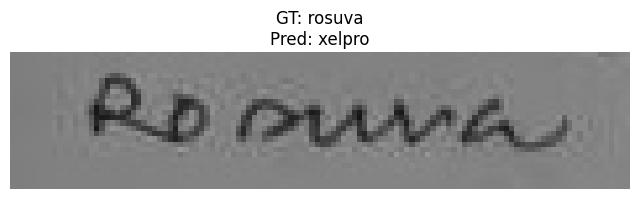

In [86]:
import random
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

def preprocess_crop_for_model(path):
    bgr = cv2.imread(path)
    if bgr is None:
        return None, None
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    pil = Image.fromarray(rgb)

    arr = resize_pad_grayscale(pil, IMG_H, MAX_W)
    x = torch.tensor(arr).unsqueeze(0).unsqueeze(0).to(device)  # (1,1,H,W)
    return rgb, x

@torch.no_grad()
def predict_text(path):
    rgb, x = preprocess_crop_for_model(path)
    if x is None:
        return None, "", "", ""
    log_probs = model(x)  # (T,1,C)
    pred = encoder.greedy_decode(log_probs)[0]
    pred_norm = normalize_text(pred)
    pred_corr = lexicon_correct(pred_norm, lexicon, threshold=70)
    return rgb, pred, pred_norm, pred_corr

# pick one random test crop
row = test_df.sample(1, random_state=None).iloc[0]
crop_path = row["crop_path"]
gt_text = row["text"]

rgb, pred_raw, pred_norm, pred_corr = predict_text(crop_path)

print("🖼 Crop:", crop_path)
print("✅ GT:", gt_text)
print("🔤 Pred (raw):", pred_raw)
print("🔤 Pred (norm):", pred_norm)
print("🧠 Pred (lexicon):", pred_corr)

plt.figure(figsize=(8,3))
plt.imshow(rgb)
plt.axis("off")
plt.title(f"GT: {gt_text}\nPred: {pred_corr}", fontsize=12)
plt.show()


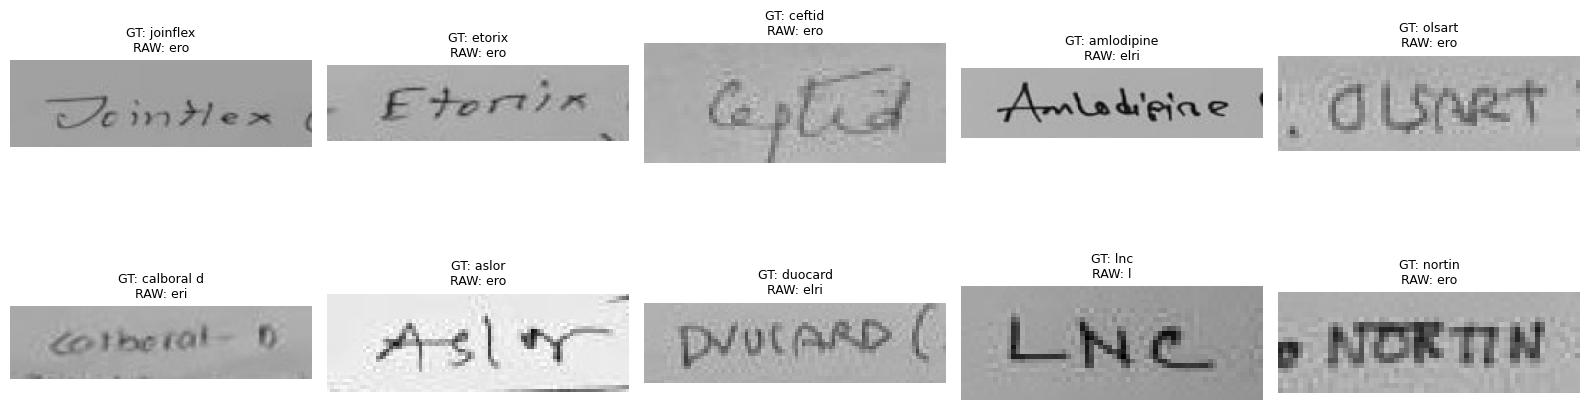

In [87]:
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import torch
import random

def preprocess_crop_raw(path):
    bgr = cv2.imread(path)
    if bgr is None:
        return None, None
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    pil = Image.fromarray(rgb)

    arr = resize_pad_grayscale(pil, IMG_H, MAX_W)
    x = torch.tensor(arr).unsqueeze(0).unsqueeze(0).to(device)
    return rgb, x

@torch.no_grad()
def predict_raw_only(path):
    rgb, x = preprocess_crop_raw(path)
    if x is None:
        return None, ""
    log_probs = model(x)
    pred = encoder.greedy_decode(log_probs)[0]
    return rgb, pred

# show 10 random test samples
sample = test_df.sample(10, random_state=42).reset_index(drop=True)

plt.figure(figsize=(16,6))
for i in range(len(sample)):
    row = sample.loc[i]
    rgb, pred = predict_raw_only(row["crop_path"])

    plt.subplot(2,5,i+1)
    plt.imshow(rgb)
    plt.axis("off")
    plt.title(f"GT: {row['text']}\nRAW: {pred}", fontsize=9)

plt.tight_layout()
plt.show()


In [88]:
import os, torch

print("BEST exists:", os.path.exists(BEST_PATH), BEST_PATH)

ckpt = torch.load(BEST_PATH, map_location=device)
print("Checkpoint keys:", ckpt.keys())
print("Vocab size in ckpt:", len(ckpt["chars"]))
print("IMG_H ckpt:", ckpt.get("IMG_H"), "MAX_W ckpt:", ckpt.get("MAX_W"))

model.load_state_dict(ckpt["model"])
model.eval()
print("✅ Loaded weights into model")


BEST exists: True /content/best_crnn_medicine_ocr.pth
Checkpoint keys: dict_keys(['model', 'chars', 'IMG_H', 'MAX_W', 'epoch', 'val_cer'])
Vocab size in ckpt: 39
IMG_H ckpt: 32 MAX_W ckpt: 256
✅ Loaded weights into model
